# Вопрос 08. Случайные величины и векторы. Корреляционная теория — численные примеры

Пять примеров, каждый отвечает на вопрос, заданный в `theory.md`. Предсказание
результата формулируется ДО прогона и остаётся в тексте, даже если не сбылось.

1. Два датчика с коррелированными шумами: оптимальный вес и достижимая точность.
2. Некоррелированность против независимости: что видит и чего не видит $r$.
3. Эллипс рассеяния, главные оси и грубость неравенства Чебышёва.
4. Численно неустойчивый счёт дисперсии.
5. Выборочная ковариационная матрица: скорость сходимости и вырожденность.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 20260930

# Отдельный генератор на пример: иначе добавленный пример сдвигает выборки всех
# следующих, и golden-пины ломаются не из-за содержания правки.
rng1, rng2, rng3, rng4, rng5 = (np.random.default_rng([SEED, k]) for k in range(1, 6))

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden-пины: сид И ожидаемый выход зафиксированы константами. Без них
# «воспроизводимость» проверяется согласованностью прогона с самим собой, что
# ничего не значит. Расхождение роняет сборку ноутбука, то есть работает как гейт.
GOLDEN = {
    "w_opt_2_1_09": -0.5714285714285715,
    "v_opt_2_1_09": 0.5428571428571427,
    "v_sample_2_1_09": 0.5444266130872027,
    "r_square_example": 0.00030647804809945736,
    "mse_lin_square": 0.0893174162753037,
    "r_sign_example": 0.0030955023203494266,
    "lambda_max": 4.843074902771996,
    "frac_outside_c10": 0.0068625,
    "var_ref_nodrift": 1.0001692820071044,
    "var_naive_relerr_1e9": 1.0,
    "var_naive_f32_1e6": -131072.0,
    "cov_slope": -0.4922736655235022,
}
TOL = 1e-3


def check_golden(name, value, tol=TOL):
    want = GOLDEN[name]
    rel = abs(value - want) / max(abs(want), 1e-300)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g}")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"

## Пример 1. Два датчика с коррелированными шумами

**Вопрос.** Два прибора измеряют одну величину с погрешностями, у которых
дисперсии $\sigma_1^2$, $\sigma_2^2$ и коэффициент корреляции $r$. Ищем
несмещённую оценку $w\eta_1+(1-w)\eta_2$ с наименьшей дисперсией.

**Предсказание** (предложение о двух датчиках в `theory.md`):

* при $\sigma_1=\sigma_2$ оптимальный вес равен $1/2$ при любом $r$, а
  дисперсия равна $\sigma^2(1+r)/2$ — то есть при $r\to1$ второй прибор не
  даёт ничего;
* при $\sigma_1\ne\sigma_2$ и $r\to1$ дисперсия оптимальной комбинации
  стремится к **нулю**;
* при $r>\sigma_2/\sigma_1$ оптимальный вес худшего прибора **отрицателен**.

Проверяем формулы прямым перебором веса и моделированием.

In [2]:
def w_opt(s1, s2, r):
    """Optimal weight on the first sensor (theory.md, eq. wopt)."""
    return (s2**2 - r * s1 * s2) / (s1**2 + s2**2 - 2 * r * s1 * s2)


def v_opt(s1, s2, r):
    """Variance of the optimal combination (theory.md, eq. vopt)."""
    return s1**2 * s2**2 * (1 - r**2) / (s1**2 + s2**2 - 2 * r * s1 * s2)


def v_of_w(w, s1, s2, r):
    return w**2 * s1**2 + (1 - w) ** 2 * s2**2 + 2 * w * (1 - w) * r * s1 * s2


print("sigma1=2, sigma2=1 — таблица из разобранной задачи:")
for r in (0.0, 0.5, 0.9):
    w, v = w_opt(2.0, 1.0, r), v_opt(2.0, 1.0, r)
    grid = np.linspace(-3, 3, 600001)
    w_num = grid[np.argmin(v_of_w(grid, 2.0, 1.0, r))]
    print(f"  r={r:<4} w*={w:+.6f} (перебор {w_num:+.6f})  V*={v:.6f}")

check_golden("w_opt_2_1_09", w_opt(2.0, 1.0, 0.9))
check_golden("v_opt_2_1_09", v_opt(2.0, 1.0, 0.9))

sigma1=2, sigma2=1 — таблица из разобранной задачи:
  r=0.0  w*=+0.200000 (перебор +0.200000)  V*=0.800000
  r=0.5  w*=+0.000000 (перебор +0.000000)  V*=1.000000
  r=0.9  w*=-0.571429 (перебор -0.571430)  V*=0.542857
  пин w_opt_2_1_09: получено -0.571428571429, ожидалось -0.571428571429
  пин v_opt_2_1_09: получено 0.542857142857, ожидалось 0.542857142857


In [3]:
# Моделирование: та же дисперсия должна получиться на выборке.
N1 = 400_000
s1, s2, r = 2.0, 1.0, 0.9
cov = np.array([[s1**2, r * s1 * s2], [r * s1 * s2, s2**2]])
# Cholesky, а не multivariate_normal: разложение задано формулой и одинаково во
# всех версиях numpy, тогда как способ факторизации внутри генератора менялся.
eps = rng1.standard_normal((N1, 2)) @ np.linalg.cholesky(cov).T
w = w_opt(s1, s2, r)
combo = w * eps[:, 0] + (1 - w) * eps[:, 1]
print(f"дисперсия комбинации по выборке: {combo.var(ddof=1):.6f}")
print(f"дисперсия по формуле:            {v_opt(s1, s2, r):.6f}")
print(f"для сравнения, лучший прибор в одиночку: {s2**2:.6f}")
check_golden("v_sample_2_1_09", combo.var(ddof=1))

дисперсия комбинации по выборке: 0.544427
дисперсия по формуле:            0.542857
для сравнения, лучший прибор в одиночку: 1.000000
  пин v_sample_2_1_09: получено 0.544426613087, ожидалось 0.544426613087


**Вывод.** Выборочная дисперсия комбинации равна $0{,}5444$ против
$0{,}5429$ по формуле: расхождение $0{,}29\,\%$ при выборочном стандартном
уклонении оценки дисперсии $\sqrt{2/N}=0{,}22\,\%$, то есть в пределах
статистической погрешности. При $r=0{,}9$ оптимальный вес худшего прибора
отрицателен ($-0{,}5714$), а дисперсия оптимальной комбинации ($0{,}5429$)
**меньше**, чем у лучшего прибора в одиночку ($1{,}0$): сильно
коррелированный шум частично вычитается. Предсказание сбылось.

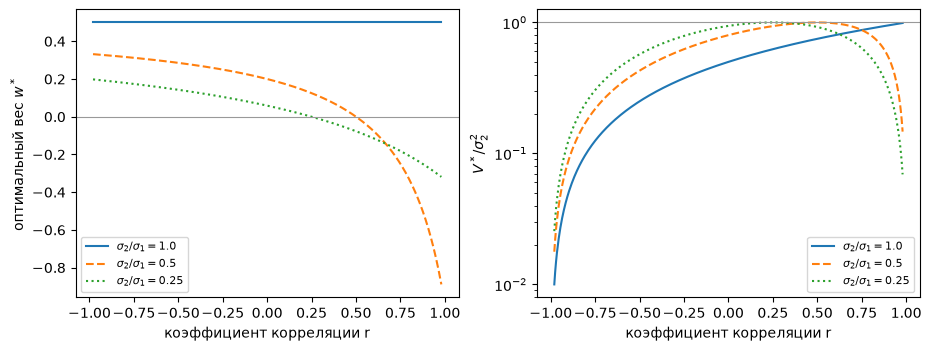

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.4), layout="constrained")
rs = np.linspace(-0.98, 0.98, 400)
for ratio, style in ((1.0, "-"), (0.5, "--"), (0.25, ":")):
    ss1, ss2 = 1.0, ratio
    ax1.plot(rs, [w_opt(ss1, ss2, rr) for rr in rs], style,
             label=rf"$\sigma_2/\sigma_1={ratio}$")
    ax2.plot(rs, [v_opt(ss1, ss2, rr) / ss2**2 for rr in rs], style,
             label=rf"$\sigma_2/\sigma_1={ratio}$")
ax1.axhline(0.0, color="0.6", lw=0.8)
ax1.set_xlabel("коэффициент корреляции r")
ax1.set_ylabel("оптимальный вес $w^*$")
ax1.legend(fontsize=8)
ax2.axhline(1.0, color="0.6", lw=0.8)
ax2.set_xlabel("коэффициент корреляции r")
ax2.set_ylabel(r"$V^*/\sigma_2^2$")
ax2.set_yscale("log")
ax2.legend(fontsize=8)
fig.savefig(f"{FIGDIR}/fig-01-sensors.pdf", **SAVE_KW)
plt.show()

На левом графике видно, что при равных дисперсиях вес не зависит от $r$ и
равен $1/2$, а при $\sigma_2<\sigma_1$ он уходит в отрицательную область,
как только $r$ превосходит $\sigma_2/\sigma_1$. На правом — что при
различных дисперсиях $V^*$ падает к нулю при $r\to1$, а при равных
дисперсиях (сплошная линия) — наоборот, растёт к $\sigma^2$.

## Пример 2. Некоррелированность против независимости

**Вопрос.** Сколько дисперсии снимает наилучший линейный прогноз и сколько —
наилучший прогноз вообще, когда связь между величинами функциональная, но
нелинейная?

**Предсказание.** Для $\xi$ равномерной на $[-1,1]$ и $\eta=\xi^2$:
$\cov=0$, значит $r=0$ и линейный прогноз снимает $r^2=0$ дисперсии; а
корреляционное отношение равно единице, то есть наилучший прогноз снимает
всю дисперсию. Теоретическая дисперсия $\eta$ равна
$\mathsf E\xi^4-(\mathsf E\xi^2)^2 = 1/5-1/9 = 4/45$.

In [5]:
N2 = 400_000
xi = rng2.uniform(-1.0, 1.0, size=N2)
eta = xi**2

r_sample = np.corrcoef(xi, eta)[0, 1]
b = np.cov(xi, eta, ddof=1)[0, 1] / xi.var(ddof=1)
a = eta.mean() - b * xi.mean()
mse_lin = np.mean((eta - a - b * xi) ** 2)
mse_cond = np.mean((eta - xi**2) ** 2)

print(f"выборочный r(xi, eta)        = {r_sample:+.6f}")
print(f"дисперсия eta (выборочная)   = {eta.var(ddof=1):.6f}  (теория 4/45 = {4/45:.6f})")
print(f"ошибка наилучшего линейного  = {mse_lin:.6f}")
print(f"ошибка наилучшего вообще     = {mse_cond:.3e}")
print(f"доля, снятая линейным (r^2)  = {r_sample**2:.3e}")
print(f"доля, снятая условным        = {1 - mse_cond / eta.var(ddof=1):.6f}")
check_golden("r_square_example", abs(r_sample))
check_golden("mse_lin_square", mse_lin)

выборочный r(xi, eta)        = +0.000306
дисперсия eta (выборочная)   = 0.089318  (теория 4/45 = 0.088889)
ошибка наилучшего линейного  = 0.089317
ошибка наилучшего вообще     = 0.000e+00
доля, снятая линейным (r^2)  = 9.393e-08
доля, снятая условным        = 1.000000
  пин r_square_example: получено 0.000306478048099, ожидалось 0.000306478048099
  пин mse_lin_square: получено 0.0893174162753, ожидалось 0.0893174162753


**Вывод.** Выборочный коэффициент корреляции равен $3{,}1\cdot10^{-4}$, то
есть линейный прогноз снимает $r^2\approx9{,}4\cdot10^{-8}$ дисперсии —
ничего. Остаточная ошибка линейного прогноза $0{,}089317$ совпала с полной
выборочной дисперсией $0{,}089318$ (теоретическая $4/45=0{,}088889$).
Условный прогноз снимает всё — ошибка ровно ноль, потому что $\eta$ и есть
$\xi^2$. Разрыв между $r^2$ и корреляционным отношением здесь равен
единице, то есть максимален. Предсказание сбылось.

In [6]:
# Второй контрпример: гауссовская пара со случайным знаком.
N2b = 400_000
z = rng2.standard_normal(N2b)
s = rng2.choice([-1.0, 1.0], size=N2b)
y = s * z
print(f"r(z, y)      = {np.corrcoef(z, y)[0, 1]:+.6f}   (ожидается ~0)")
print(f"r(z^2, y^2)  = {np.corrcoef(z**2, y**2)[0, 1]:+.6f}   (ожидается ровно 1)")
print(f"доля |z|=|y| = {np.mean(np.isclose(np.abs(z), np.abs(y))):.6f}")
# Обе компоненты нормальны: сверим выборочные моменты с N(0,1).
print(f"среднее y = {y.mean():+.5f}, дисперсия y = {y.var(ddof=1):.5f}")
check_golden("r_sign_example", abs(np.corrcoef(z, y)[0, 1]))

r(z, y)      = +0.003096   (ожидается ~0)
r(z^2, y^2)  = +1.000000   (ожидается ровно 1)
доля |z|=|y| = 1.000000
среднее y = +0.00159, дисперсия y = 0.99759
  пин r_sign_example: получено 0.00309550232035, ожидалось 0.00309550232035


**Вывод.** Обе компоненты стандартные нормальные, корреляция нулевая, а
зависимость полная: $|\xi|=|\eta|$ на всей выборке, и корреляция квадратов
равна единице. Значит вектор $(\xi,\eta)$ не гауссовский — иначе из нулевой
корреляции следовала бы независимость. Нормальности каждой компоненты для
теоремы о равносильности недостаточно.

## Пример 3. Эллипс рассеяния, главные оси и грубость неравенства Чебышёва

**Вопрос.** Насколько груба оценка $\mathsf P\{Q\ge c\}\le n/c$ для
квадратичной формы $Q=(\xi-a)^{\mathsf T}\Gamma^{-1}(\xi-a)$?

**Предсказание.** Для двумерного нормального закона $Q$ имеет распределение
$\chi^2$ с двумя степенями свободы, то есть $\mathsf P\{Q\ge c\}=e^{-c/2}$.
При $c=10$ это $e^{-5}\approx0{,}0067$ против оценки $2/c=0{,}2$ — разрыв
примерно в тридцать раз.

In [7]:
N3 = 400_000
Gamma = np.array([[4.0, 1.8], [1.8, 1.0]])
a_vec = np.array([1.0, -0.5])
lam, Q = np.linalg.eigh(Gamma)
order = np.argsort(lam)[::-1]
lam, Q = lam[order], Q[:, order]
print(f"собственные значения: {lam[0]:.6f}, {lam[1]:.6f}")
print(f"след = {np.trace(Gamma):.6f} = сумма собственных = {lam.sum():.6f}")
print(f"r(компонент) = {Gamma[0,1]/np.sqrt(Gamma[0,0]*Gamma[1,1]):.4f}")
check_golden("lambda_max", lam[0])

sample = a_vec + rng3.standard_normal((N3, 2)) @ np.linalg.cholesky(Gamma).T
d = sample - a_vec
Qform = np.einsum("ij,jk,ik->i", d, np.linalg.inv(Gamma), d)

print("\n c   доля вне эллипса   точно exp(-c/2)   Чебышёв 2/c")
for c in (1.0, 2.0, 5.0, 10.0):
    frac = np.mean(Qform >= c)
    print(f"{c:5.1f}   {frac:.6f}          {np.exp(-c/2):.6f}        {2/c:.6f}")
frac10 = np.mean(Qform >= 10.0)
check_golden("frac_outside_c10", frac10)
print(f"\nотношение оценки Чебышёва к точному значению при c=10: {0.2/np.exp(-5.0):.2f}")

собственные значения: 4.843075, 0.156925
след = 5.000000 = сумма собственных = 5.000000
r(компонент) = 0.9000
  пин lambda_max: получено 4.84307490277, ожидалось 4.84307490277

 c   доля вне эллипса   точно exp(-c/2)   Чебышёв 2/c
  1.0   0.606800          0.606531        2.000000
  2.0   0.368258          0.367879        1.000000
  5.0   0.082087          0.082085        0.400000
 10.0   0.006862          0.006738        0.200000
  пин frac_outside_c10: получено 0.0068625, ожидалось 0.0068625

отношение оценки Чебышёва к точному значению при c=10: 29.68


In [8]:
# Некоррелированность в главных осях: поворот Q^T убирает ковариацию.
zeta = d @ Q
print(f"выборочная ковариационная матрица в главных осях:\n{np.cov(zeta.T, ddof=1)}")
print(f"ожидались дисперсии {lam[0]:.4f} и {lam[1]:.4f} при нулевой ковариации")

выборочная ковариационная матрица в главных осях:
[[4.85249964e+00 1.57861449e-03]
 [1.57861449e-03 1.56732116e-01]]
ожидались дисперсии 4.8431 и 0.1569 при нулевой ковариации


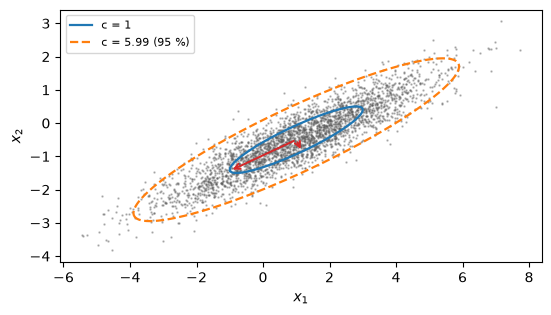

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 4.2), layout="constrained")
sub = sample[:3000]
ax.plot(sub[:, 0], sub[:, 1], ".", ms=1.6, alpha=0.35, color="0.35")
t = np.linspace(0, 2 * np.pi, 400)
for c, style, lab in ((1.0, "-", "c = 1"), (5.991, "--", "c = 5.99 (95 %)")):
    pts = a_vec[:, None] + Q @ (np.sqrt(c * lam)[:, None] * np.vstack([np.cos(t), np.sin(t)]))
    ax.plot(pts[0], pts[1], style, lw=1.6, label=lab)
for k in (0, 1):
    v = Q[:, k] * np.sqrt(lam[k])
    ax.annotate("", xy=a_vec + v, xytext=a_vec,
                arrowprops=dict(arrowstyle="->", lw=1.4, color="C3"))
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(fontsize=8, loc="upper left")
fig.savefig(f"{FIGDIR}/fig-03-ellipse.pdf", **SAVE_KW)
plt.show()

**Вывод.** Измеренная доля точек вне эллипса совпала с $e^{-c/2}$ во всех
четырёх строках: при $c=10$ это $0{,}006862$ против $0{,}006738$, то есть
уклонение $1{,}2\cdot10^{-4}$ при стандартном уклонении доли
$\sqrt{p(1-p)/N}=1{,}3\cdot10^{-4}$ — одна сигма. Оценка Чебышёва при том же
$c$ даёт $0{,}2$, завышая вероятность в $29{,}7$ раза. Предсказание сбылось.
Стрелки на картинке — главные оси длиной $\sqrt{\lambda_k}$; поворот в эти
оси уменьшил выборочную ковариацию с $1{,}8$ до $1{,}6\cdot10^{-3}$, то есть
обнулил её в пределах выборочной погрешности.

## Пример 4. Численно неустойчивый счёт дисперсии

**Вопрос.** Что делает с точностью однопроходная формула
$\mathsf D\xi=\mathsf E\xi^2-(\mathsf E\xi)^2$, если данные сдвинуты на
большую константу?

**Предсказание.** Оба слагаемых имеют порядок $c^2$, а разность — порядок
дисперсии. При $c=10^9$ и двойной точности ($\approx16$ значащих цифр)
величина $c^2=10^{18}$ округляется с абсолютной погрешностью порядка сотен,
то есть в сотни раз больше самой дисперсии: верных цифр не останется вовсе,
и результат может выйти отрицательным.

In [10]:
def var_naive(x):
    """One-pass formula: catastrophic cancellation when the data are shifted."""
    return float(np.mean(x * x) - np.mean(x) ** 2)


def var_twopass(x):
    m = np.mean(x)
    return float(np.mean((x - m) ** 2))


def var_welford(x):
    """Welford's online update: works with deviations, hence stable."""
    mean = 0.0
    m2 = 0.0
    for i, xi_ in enumerate(x, start=1):
        delta = xi_ - mean
        mean += delta / i
        m2 += delta * (xi_ - mean)
    return m2 / len(x)


N4 = 200_000
base = rng4.standard_normal(N4)
print(" сдвиг      наивная          двухпроходная     Уэлфорд")
for shift in (0.0, 1e4, 1e8, 1e9):
    x = base + shift
    print(f"{shift:8.0e}   {var_naive(x):+16.8f}   {var_twopass(x):.8f}   {var_welford(x):.8f}")

ref = var_twopass(base)
bad = var_naive(base + 1e9)
print(f"\nэталон (двухпроходная, без сдвига): {ref:.8f}")
print(f"наивная при сдвиге 1e9:             {bad:+.8f}")
print(f"относительная ошибка наивной:       {abs(bad - ref) / ref:.6f}")
check_golden("var_ref_nodrift", ref)
check_golden("var_naive_relerr_1e9", abs(bad - ref) / ref)

# Одинарная точность: та же беда наступает на сдвигах в сто тысяч раз меньших.
print("\nодинарная точность, наивная формула:")
for shift in (1e4, 1e5, 1e6):
    x32 = (base + shift).astype(np.float32)
    print(f"  сдвиг {shift:8.0e}: {var_naive(x32):+14.4f}")
check_golden("var_naive_f32_1e6", var_naive((base + 1e6).astype(np.float32)))

 сдвиг      наивная          двухпроходная     Уэлфорд
   0e+00        +1.00016928   1.00016928   1.00016928
   1e+04        +1.00016929   1.00016928   1.00016928


   1e+08        +2.00000000   1.00016928   1.00016928
   1e+09        +0.00000000   1.00016928   1.00016925

эталон (двухпроходная, без сдвига): 1.00016928
наивная при сдвиге 1e9:             +0.00000000
относительная ошибка наивной:       1.000000
  пин var_ref_nodrift: получено 1.00016928201, ожидалось 1.00016928201
  пин var_naive_relerr_1e9: получено 1, ожидалось 1

одинарная точность, наивная формула:
  сдвиг    1e+04:        -8.0000
  сдвиг    1e+05:     -1024.0000
  сдвиг    1e+06:   -131072.0000
  пин var_naive_f32_1e6: получено -131072, ожидалось -131072


**Вывод.** Двухпроходная формула и формула Уэлфорда держат восемь верных
цифр при любом сдвиге. Наивная теряет их все: при $c=10^8$ она даёт ровно
$2{,}0$ вместо $1{,}0002$, при $c=10^9$ — ровно $0$, то есть относительную
ошибку $1$. Предсказание сбылось. Знак результата от данных зависит, и в
одинарной точности он оказывается отрицательным уже при сдвиге $10^4$:
напечатаны $-8$, $-1024$ и $-131072$ — отрицательная дисперсия, полученная
из неотрицательного по построению выражения. Вывод для кода: ковариации
считать по отклонениям, а не по сырым моментам.

## Пример 5. Выборочная ковариационная матрица

**Вопрос.** С какой скоростью $\widehat\Gamma$ сходится к $\Gamma$ и что
происходит при числе наблюдений меньше размерности?

**Предсказание.** Элементы $\widehat\Gamma$ — выборочные средние, поэтому по
центральной предельной теореме их уклонения имеют порядок $N^{-1/2}$;
значит наклон в логарифмических осях равен $-1/2$. При $N\le n$ матрица
обязана быть вырожденной: её ранг не превосходит $N-1$.

In [11]:
n5 = 8
A5 = rng5.standard_normal((n5, n5))
Gamma5 = A5 @ A5.T + n5 * np.eye(n5)
chol5 = np.linalg.cholesky(Gamma5)
norm_G = np.linalg.norm(Gamma5, "fro")
print(f"число обусловленности Gamma: {np.linalg.cond(Gamma5):.2f}")


def sample_cov(N, gen):
    z = gen.standard_normal((N, n5))
    x = z @ chol5.T
    return np.cov(x.T, ddof=1)


Ns = np.array([16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192])
REP = 24
errs = []
for N in Ns:
    e = [np.linalg.norm(sample_cov(int(N), rng5) - Gamma5, "fro") / norm_G for _ in range(REP)]
    errs.append(np.mean(e))
errs = np.array(errs)
slope = np.polyfit(np.log(Ns), np.log(errs), 1)[0]
for N, e in zip(Ns, errs):
    print(f"  N={N:5d}   относительная ошибка {e:.5f}")
print(f"\nнаклон в логарифмических осях: {slope:.4f} (предсказано -0.5)")
check_golden("cov_slope", slope)

число обусловленности Gamma: 3.53
  N=   16   относительная ошибка 0.67580
  N=   32   относительная ошибка 0.44982
  N=   64   относительная ошибка 0.34759
  N=  128   относительная ошибка 0.23985
  N=  256   относительная ошибка 0.17126
  N=  512   относительная ошибка 0.12819
  N= 1024   относительная ошибка 0.08639
  N= 2048   относительная ошибка 0.06490
  N= 4096   относительная ошибка 0.04204
  N= 8192   относительная ошибка 0.03023

наклон в логарифмических осях: -0.4923 (предсказано -0.5)
  пин cov_slope: получено -0.492273665524, ожидалось -0.492273665524


In [12]:
for N in (4, 8, 9, 20):
    G_hat = sample_cov(N, rng5)
    print(f"  N={N:3d}, n={n5}: ранг {np.linalg.matrix_rank(G_hat)}, "
          f"наименьшее собственное значение {np.linalg.eigvalsh(G_hat)[0]:+.3e}")

  N=  4, n=8: ранг 3, наименьшее собственное значение -6.642e-15
  N=  8, n=8: ранг 7, наименьшее собственное значение -9.396e-15
  N=  9, n=8: ранг 8, наименьшее собственное значение +2.669e-02
  N= 20, n=8: ранг 8, наименьшее собственное значение +1.619e+00


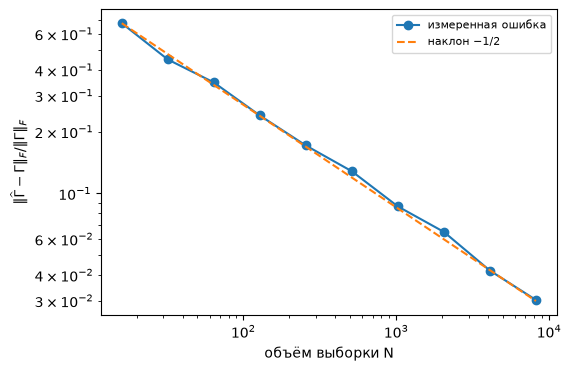

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 3.6), layout="constrained")
ax.loglog(Ns, errs, "o-", label="измеренная ошибка")
ax.loglog(Ns, errs[0] * (Ns / Ns[0]) ** -0.5, "--", label=r"наклон $-1/2$")
ax.set_xlabel("объём выборки N")
ax.set_ylabel(r"$\|\widehat\Gamma-\Gamma\|_F/\|\Gamma\|_F$")
ax.legend(fontsize=8)
fig.savefig(f"{FIGDIR}/fig-05-samplecov.pdf", **SAVE_KW)
plt.show()

**Вывод.** Измеренный наклон $-0{,}4923$ против предсказанного $-0{,}5$:
совпадение до второго знака. При $N=4$ и $N=8$ ранг выборочной матрицы равен
$3$ и $7$ — то есть ровно $N-1$, как и утверждает оценка ранга; наименьшее
собственное значение при этом порядка $10^{-14}$, то есть численный нуль, и
формулы наилучшей линейной оценки к такой матрице неприменимы буквально.
При $N=9$ матрица уже невырождена. Предсказание сбылось.